# Метод К ближайших соседей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
iris = load_iris()
features = iris.data
data = pd.DataFrame(features, columns=iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
X = data.iloc[:, [0, 2]]   # sepal length (cm) и petal length (cm)
y = iris.target
print(X.shape, y.shape)

(150, 2) (150,)


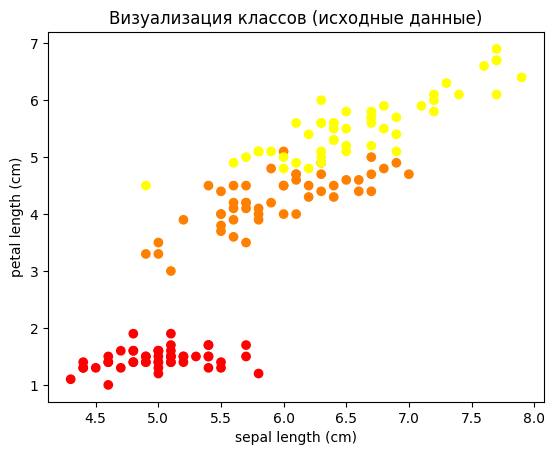

In [4]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.title("Визуализация классов (исходные данные)")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

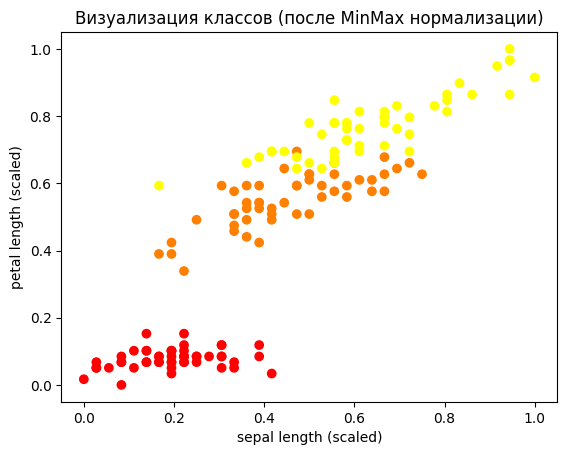

In [6]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')
plt.title("Визуализация классов (после MinMax нормализации)")
plt.xlabel('sepal length (scaled)')
plt.ylabel('petal length (scaled)')
plt.show()

In [7]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)
y_pred = knn.predict(X_scaled)

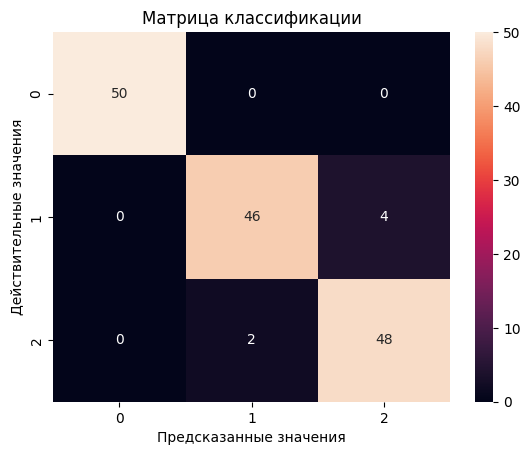

In [8]:
plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [9]:
print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.96      0.94        48
           2       0.96      0.92      0.94        52

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


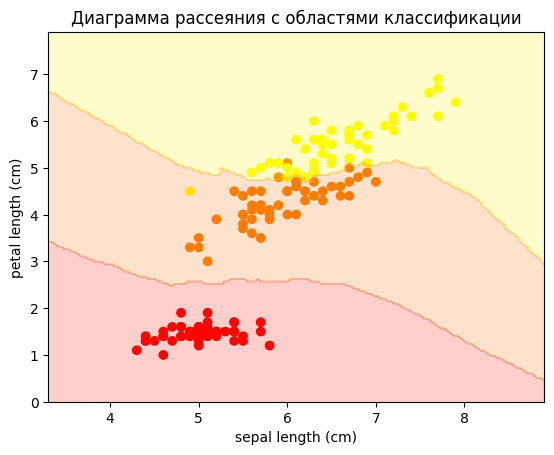

In [10]:
# Создаём сетку в пространстве исходных признаков
X0 = np.linspace(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)
XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

# Нормализуем сетку тем же scaler'ом
XX_scaled = scaler.transform(XX)

# Предсказываем классы для каждой точки сетки
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

# Рисуем контуры и исходные точки
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()

In [11]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)

print("Предсказанный класс:", knn.predict(observation_new_scaled))
print("Вероятности классов:", knn.predict_proba(observation_new_scaled))

Предсказанный класс: [2]
Вероятности классов: [[0. 0. 1.]]


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [12]:
distances, indices = knn.kneighbors(observation_new_scaled)
print("Расстояния до 3 ближайших соседей:", distances)
print("Индексы (номера строк) этих соседей в X_scaled:", indices)
print("Координаты (в нормализованном пространстве):")
for i in indices[0]:
    print(X_scaled[i])

Расстояния до 3 ближайших соседей: [[0.03254042 0.05555556 0.08503951]]
Индексы (номера строк) этих соседей в X_scaled: [[121 113 142]]
Координаты (в нормализованном пространстве):
[0.36111111 0.66101695]
[0.38888889 0.6779661 ]
[0.41666667 0.69491525]


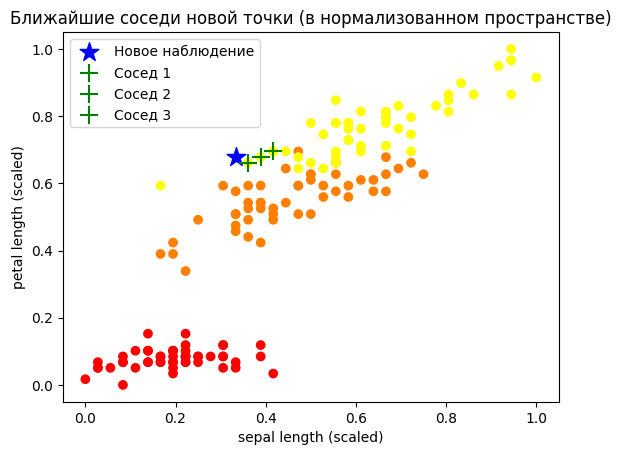

In [13]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')
plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], 
            marker='*', s=200, color='b', label='Новое наблюдение')

# Отмечаем трёх ближайших соседей
neighbors = indices[0]
plt.scatter(X_scaled[neighbors[0], 0], X_scaled[neighbors[0], 1], 
            marker='+', s=150, color='g', label='Сосед 1')
plt.scatter(X_scaled[neighbors[1], 0], X_scaled[neighbors[1], 1], 
            marker='+', s=150, color='g', label='Сосед 2')
plt.scatter(X_scaled[neighbors[2], 0], X_scaled[neighbors[2], 1], 
            marker='+', s=150, color='g', label='Сосед 3')

plt.legend()
plt.title("Ближайшие соседи новой точки (в нормализованном пространстве)")
plt.xlabel('sepal length (scaled)')
plt.ylabel('petal length (scaled)')
plt.show()

# Задание для самостоятельного решения

## Задание 1: Последний график в исходном пространстве признаков

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


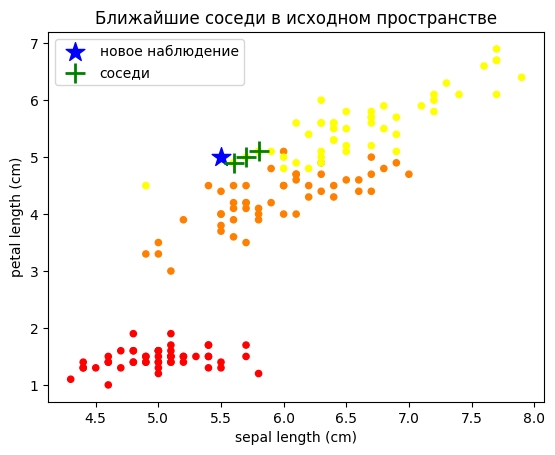

In [14]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
distances, indices = knn.kneighbors(observation_new_scaled)
neighbors = indices[0]

# Ближайшие соседи в исходных координатах (inverting scale)
X_orig = scaler.inverse_transform(X_scaled)

plt.scatter(X_orig[:, 0], X_orig[:, 1], c=y, cmap='autumn', s=20)
plt.scatter(*observation_new[0], marker='*', s=200, color='b', label='новое наблюдение')
plt.scatter(X_orig[neighbors, 0], X_orig[neighbors, 1],
            marker='+', s=200, color='g', linewidths=2, label='соседи')
plt.xlabel('sepal length (cm)'); plt.ylabel('petal length (cm)')
plt.title("Ближайшие соседи в исходном пространстве")
plt.legend(); plt.show()

## Задание 2: Разные значения k — области классификации и метрики

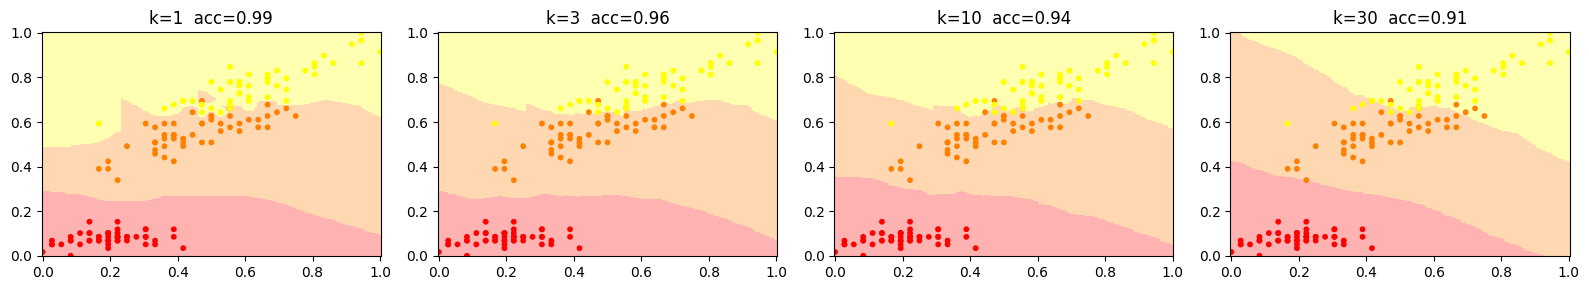

In [15]:
ks = [1, 3, 10, 30]
fig, axes = plt.subplots(1, len(ks), figsize=(16, 3))

xx0 = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 200)
xx1 = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 200)
g0, g1 = np.meshgrid(xx0, xx1)

for ax, k in zip(axes, ks):
    m = KNeighborsClassifier(n_neighbors=k).fit(X_scaled, y)
    Z = m.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
    ax.pcolormesh(g0, g1, Z, cmap='autumn', alpha=0.3)
    ax.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap='autumn', s=10)
    ax.set_title(f"k={k}  acc={m.score(X_scaled,y):.2f}")

plt.tight_layout(); plt.show()
# Вывод: малое k — сложная граница (переобучение), большое k — сглаженная.

## Задание 3: Сдвиг наблюдения за пределы выборки — поведение нормализации

In [16]:
# MinMaxScaler масштабирует по мин/макс обучающей выборки.
# Точки за пределами диапазона дают значения <0 или >1.
test_points = [[5.5, 5], [0, 0], [10, 20], [-5, -10]]
for pt in test_points:
    scaled = scaler.transform([pt])[0]
    pred   = knn.predict([scaled])[0]
    print(f"исходная={pt}  нормализованная={scaled.round(3)}  класс={pred}")

исходная=[5.5, 5]  нормализованная=[0.333 0.678]  класс=2
исходная=[0, 0]  нормализованная=[-1.194 -0.169]  класс=0
исходная=[10, 20]  нормализованная=[1.583 3.22 ]  класс=2
исходная=[-5, -10]  нормализованная=[-2.583 -1.864]  класс=0


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Задание 4: Разные метрики расстояния — визуализация ближайших соседей

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


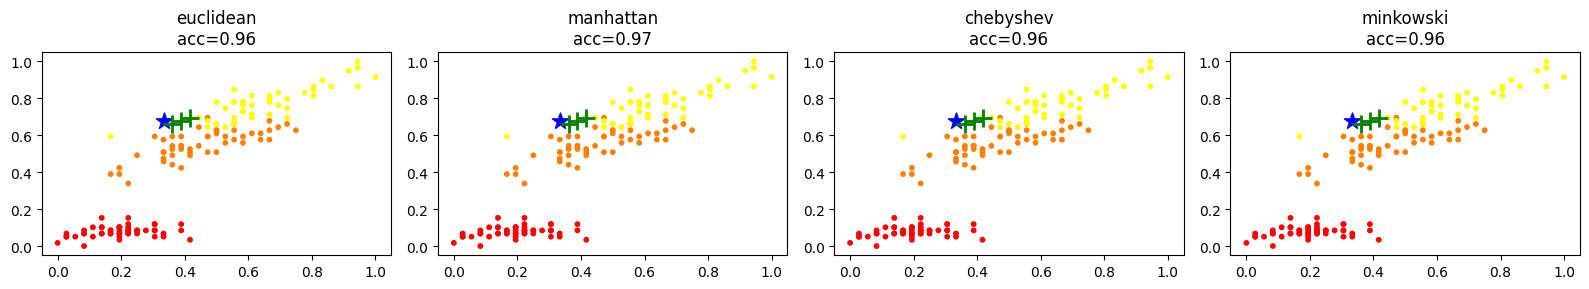

In [17]:
metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
obs_sc = scaler.transform([[5.5, 5]])

fig, axes = plt.subplots(1, len(metrics_list), figsize=(16, 3))
for ax, metric in zip(axes, metrics_list):
    m = KNeighborsClassifier(n_neighbors=3, metric=metric).fit(X_scaled, y)
    _, idx = m.kneighbors(obs_sc)
    nbrs = idx[0]
    ax.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap='autumn', s=10)
    ax.scatter(*obs_sc[0], marker='*', s=150, color='b')
    ax.scatter(X_scaled[nbrs,0], X_scaled[nbrs,1], marker='+', s=150, color='g', linewidths=2)
    ax.set_title(f"{metric}\nacc={m.score(X_scaled,y):.2f}")

plt.tight_layout(); plt.show()

## Задания 5–7: Полный Iris — разные k, weights, график accuracy(k)

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Полный датасет (4 признака)
X_full = iris.data
X_full_sc = MinMaxScaler().fit_transform(X_full)

# Задание 5: разные k
print("=== Задание 5: разные k (полный Iris) ===")
for k in [1, 3, 5, 10, 20]:
    acc = KNeighborsClassifier(n_neighbors=k).fit(X_full_sc, y).score(X_full_sc, y)
    print(f"k={k:>2}  accuracy={acc:.4f}")

# Задание 6: uniform vs distance
print("\n=== Задание 6: weights ===")
for w in ['uniform', 'distance']:
    acc = KNeighborsClassifier(n_neighbors=5, weights=w).fit(X_full_sc, y).score(X_full_sc, y)
    print(f"weights={w:<10}  accuracy={acc:.4f}")

=== Задание 5: разные k (полный Iris) ===
k= 1  accuracy=1.0000
k= 3  accuracy=0.9667
k= 5  accuracy=0.9600
k=10  accuracy=0.9667
k=20  accuracy=0.9733

=== Задание 6: weights ===
weights=uniform     accuracy=0.9600
weights=distance    accuracy=1.0000


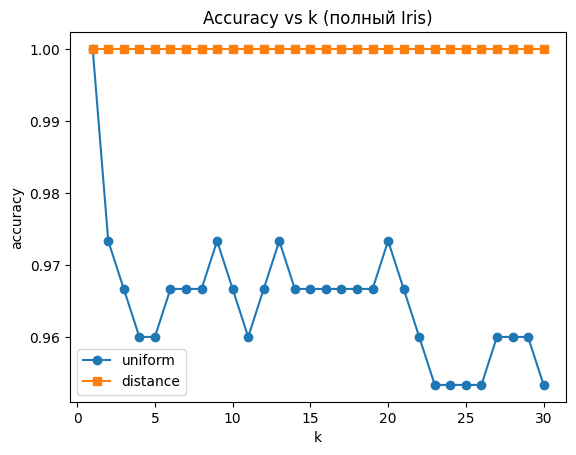

In [19]:
# Задание 7: график accuracy(k)
k_range = range(1, 31)
accs_unif = [KNeighborsClassifier(n_neighbors=k).fit(X_full_sc, y).score(X_full_sc, y) for k in k_range]
accs_dist = [KNeighborsClassifier(n_neighbors=k, weights='distance').fit(X_full_sc, y).score(X_full_sc, y) for k in k_range]

plt.plot(k_range, accs_unif, marker='o', label='uniform')
plt.plot(k_range, accs_dist, marker='s', label='distance')
plt.xlabel("k"); plt.ylabel("accuracy")
plt.title("Accuracy vs k (полный Iris)")
plt.legend(); plt.show()
# Вывод: при k=1 accuracy=1.0 (переобучение), оптимум около k=5–10.

## Задание 8: KNN-регрессия на California Housing

=== KNeighborsRegressor — California Housing ===
k= 3  R²=0.8500  MAE=0.2965
k= 5  R²=0.8083  MAE=0.3375
k=10  R²=0.7719  MAE=0.3712
k=20  R²=0.7389  MAE=0.4005


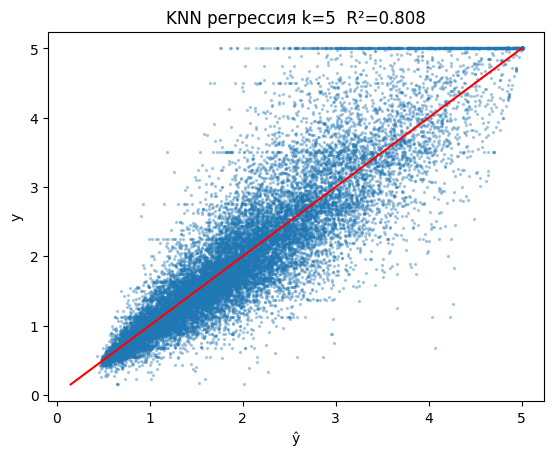

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_absolute_error

ca = fetch_california_housing()
X_ca = MinMaxScaler().fit_transform(ca.data)
y_ca = ca.target

# Сравниваем несколько k
print("=== KNeighborsRegressor — California Housing ===")
for k in [3, 5, 10, 20]:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_ca, y_ca)
    yp = m.predict(X_ca)
    print(f"k={k:>2}  R²={r2_score(y_ca,yp):.4f}  MAE={mean_absolute_error(y_ca,yp):.4f}")

# Визуализация: ŷ vs y для лучшей модели
best_kr = KNeighborsRegressor(n_neighbors=5).fit(X_ca, y_ca)
yp_best = best_kr.predict(X_ca)
plt.scatter(yp_best, y_ca, s=2, alpha=0.3)
plt.plot([y_ca.min(), y_ca.max()], [y_ca.min(), y_ca.max()], 'r')
plt.xlabel("ŷ"); plt.ylabel("y")
plt.title(f"KNN регрессия k=5  R²={r2_score(y_ca, yp_best):.3f}")
plt.show()